# GPT-2 Exploration

This notebook explores a pretrained GPT-2 model and compares
its tokenization, architecture, attention mechanisms, and
text generation with our Tiny GPT poem generator.

In [9]:
!pip install transformers torch

In [10]:
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel

In [11]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
print(tokenizer)

GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})


## 2. Exploring GPT-2 Tokenization

GPT-2 does not process raw text directly. It first converts text into
tokens, and then converts those tokens into numerical token IDs.

We will examine:
- The original text
- The tokens created by GPT-2
- The numerical token IDs
- How the IDs can be converted back into text

In [12]:
prompt = "The moon shines over the hills"

# Convert text into GPT-2 tokens
tokens = tokenizer.tokenize(prompt)

# Convert text into numerical token IDs
token_ids = tokenizer.encode(prompt)

# Convert token IDs back into text
decoded_text = tokenizer.decode(token_ids)

print("Original text:")
print(prompt)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

print("\nDecoded text:")
print(decoded_text)

Original text:
The moon shines over the hills

Tokens:
['The', 'Ġmoon', 'Ġshines', 'Ġover', 'Ġthe', 'Ġhills']

Token IDs:
[464, 8824, 32481, 625, 262, 18639]

Decoded text:
The moon shines over the hills


## 2.5 Understanding GPT-2's Byte-Level BPE Tokenization

GPT-2 uses byte-level Byte Pair Encoding (BPE).

Instead of requiring every possible word to exist as a separate vocabulary
entry, GPT-2 can represent words using smaller subword pieces.

Common words may be represented by one token, while uncommon or longer
words may be split into multiple tokens.

This allows GPT-2 to handle a very large variety of words while using a
fixed vocabulary of 50,257 tokens.

In [13]:
examples = [
    "moon",
    "beautiful",
    "unbelievable",
    "Kigali",
    "transformer",
    "internationalization"
]

for text in examples:
    tokens = tokenizer.tokenize(text)

    print(f"Text: {text}")
    print(f"Tokens: {tokens}")
    print(f"Number of tokens: {len(tokens)}")
    print()

Text: moon
Tokens: ['moon']
Number of tokens: 1

Text: beautiful
Tokens: ['beaut', 'iful']
Number of tokens: 2

Text: unbelievable
Tokens: ['un', 'bel', 'iev', 'able']
Number of tokens: 4

Text: Kigali
Tokens: ['K', 'ig', 'ali']
Number of tokens: 3

Text: transformer
Tokens: ['trans', 'former']
Number of tokens: 2

Text: internationalization
Tokens: ['international', 'ization']
Number of tokens: 2



## 4. Loading the Pretrained GPT-2 Model

GPT-2 is a pretrained Transformer language model.

Unlike Tiny GPT, we are not training GPT-2 from scratch here.
We will open the pretrained model and inspect its architecture,
embeddings, attention heads, and text-generation behavior.

In [14]:
# Load the pretrained GPT-2 model
model = GPT2LMHeadModel.from_pretrained("gpt2")

# Put the model in evaluation mode
model.eval()

# Select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the selected device
model = model.to(device)

print("Device:", device)
print("Model loaded successfully!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Device: cuda
Model loaded successfully!


In [15]:
sample = "Love is"

print("Original text:")
print(sample)

# Tiny GPT tokenization: character-level
tiny_tokens = list(sample)

# GPT-2 tokenization: BPE
gpt2_tokens = tokenizer.tokenize(sample)

print("Original:", sample)

print("\nTiny GPT")
print("Tokens:", tiny_tokens)
print("Number of tokens:", len(tiny_tokens))

print("\nGPT-2")
print("Tokens:", gpt2_tokens)
print("Number of tokens:", len(gpt2_tokens))

Original text:
Love is
Original: Love is

Tiny GPT
Tokens: ['L', 'o', 'v', 'e', ' ', 'i', 's']
Number of tokens: 7

GPT-2
Tokens: ['Love', 'Ġis']
Number of tokens: 2


### 2.8 Tiny GPT vs GPT-2 Tokenization

Both models were given the same input: "Love is".

Tiny GPT uses character-level tokenization, producing 7 tokens:
['L', 'o', 'v', 'e', ' ', 'i', 's']

GPT-2 uses Byte-Level BPE tokenization, producing only 2 tokens:
['Love', 'Ġis']

This shows that Tiny GPT represents text character by character,
while GPT-2 can represent common words or subword units as larger
tokens. Therefore, GPT-2 generally requires fewer tokens to represent
the same natural-language text.

In [16]:
!pwd

/content


---
# Task 3 — GPT-2 Architecture & Embeddings

**Owner:** Member 2

This section investigates the architecture of the pretrained GPT-2 model:
its configuration, embedding layers, transformer block components,
feed-forward sublayer, output head, parameter count, and a side-by-side
comparison with our Tiny GPT model.

## 3.1  Load the Pretrained GPT-2 Model

The model was already loaded above in Section 4.
Here we confirm it is ready and inspect its full configuration object.

In [17]:
# Model is already loaded above as `model`
# Confirm it is in eval mode on the correct device
print("Model class  :", model.__class__.__name__)
print("Device       :", next(model.parameters()).device)
print("Training mode:", model.training, " (False = eval mode)")
print()
print("Full configuration:")
print(model.config)

Model class  : GPT2LMHeadModel
Device       : cuda:0
Training mode: False  (False = eval mode)

Full configuration:
GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings":

## 3.2  Model Dimensions

GPT-2's key dimensions are stored in `model.config`.

| Property | Attribute | Meaning |
|---|---|---|
| Vocabulary size | `vocab_size` | Number of possible tokens |
| Context length | `n_positions` | Maximum sequence length |
| Hidden / embedding size | `n_embd` | Width of each token vector |
| Number of transformer layers | `n_layer` | Depth of the model |
| Number of attention heads | `n_head` | Parallel attention streams per layer |

In [18]:
cfg = model.config

print("===== GPT-2 (small) Configuration =====")
print(f"Vocabulary size   : {cfg.vocab_size:,}")
print(f"Context length    : {cfg.n_positions:,} tokens")
print(f"Embedding size    : {cfg.n_embd}")
print(f"Number of layers  : {cfg.n_layer}")
print(f"Attention heads   : {cfg.n_head}")
print(f"Head dimension    : {cfg.n_embd // cfg.n_head}  (n_embd / n_head)")
print(f"FFN inner size    : {4 * cfg.n_embd}  (4 x n_embd)")
print(f"Activation        : {cfg.activation_function}")

===== GPT-2 (small) Configuration =====
Vocabulary size   : 50,257
Context length    : 1,024 tokens
Embedding size    : 768
Number of layers  : 12
Attention heads   : 12
Head dimension    : 64  (n_embd / n_head)
FFN inner size    : 3072  (4 x n_embd)
Activation        : gelu_new


**Recorded values for GPT-2 small:**

| Dimension | Value |
|---|---|
| Vocabulary size | 50,257 |
| Context length | 1,024 tokens |
| Hidden / embedding size | 768 |
| Number of layers | 12 |
| Number of attention heads | 12 |
| Head dimension | 64 |
| FFN inner size | 3,072 (4 x 768) |

## 3.3  Embeddings: Token Embeddings and Positional Embeddings

### Why two separate embedding tables?

A transformer processes all tokens in parallel, so it has no built-in
notion of sequence order. Two embedding tables solve different problems:

| Embedding | Purpose |
|---|---|
| **Token embedding** (`wte`) | Maps each token ID to a dense vector that captures the token's *meaning*. |
| **Positional embedding** (`wpe`) | Maps each position index (0 to 1023) to a vector that encodes *where* the token sits in the sequence. |

The two vectors are **added** together before the first transformer block,
giving every token a representation that carries both identity and position.

Without positional embeddings the model would treat
`"the cat sat"` and `"sat cat the"` identically, because attention has no
other way to distinguish positions.

In [19]:
wte = model.transformer.wte   # token embedding table
wpe = model.transformer.wpe   # positional embedding table

print("Token embedding table (wte)      :", wte)
print()
print("Positional embedding table (wpe) :", wpe)
print()
print("Token embedding weight shape     :", wte.weight.shape,
      "  -> (vocab_size, n_embd)")
print("Positional embedding weight shape:", wpe.weight.shape,
      "  -> (n_positions, n_embd)")

Token embedding table (wte)      : Embedding(50257, 768)

Positional embedding table (wpe) : Embedding(1024, 768)

Token embedding weight shape     : torch.Size([50257, 768])   -> (vocab_size, n_embd)
Positional embedding weight shape: torch.Size([1024, 768])   -> (n_positions, n_embd)


In [20]:
# Demonstrate token emb + position emb -> combined input
sample_text = "The moon shines over the hills"
token_ids_t = tokenizer.encode(sample_text, return_tensors="pt").to(device)

T = token_ids_t.size(1)

tok_embs = wte(token_ids_t)                    # (1, T, 768)
pos_ids  = torch.arange(T, device=device)      # [0, 1, ..., T-1]
pos_embs = wpe(pos_ids)                        # (T, 768)
combined = tok_embs + pos_embs                 # (1, T, 768)

print("Input text        :", sample_text)
print("Tokens            :", tokenizer.tokenize(sample_text))
print("Sequence length T :", T)
print()
print("Token embedding shape    :", tok_embs.shape, " (batch, T, n_embd)")
print("Position embedding shape :", pos_embs.shape, " (T, n_embd)")
print("Combined shape           :", combined.shape, " (batch, T, n_embd)")

Input text        : The moon shines over the hills
Tokens            : ['The', 'Ġmoon', 'Ġshines', 'Ġover', 'Ġthe', 'Ġhills']
Sequence length T : 6

Token embedding shape    : torch.Size([1, 6, 768])  (batch, T, n_embd)
Position embedding shape : torch.Size([6, 768])  (T, n_embd)
Combined shape           : torch.Size([1, 6, 768])  (batch, T, n_embd)


## 3.4  Transformer Block Components

GPT-2 stacks 12 identical transformer blocks accessible via `model.transformer.h[i]`.

Each block applies these components in order:

```
Input
  |
  |-- LayerNorm 1 (ln_1)
  |
  |-- Masked Multi-Head Self-Attention (attn)
  |       causal mask prevents attending to future tokens
  |
  |-- Residual connection  (add original input back)
  |
  |-- LayerNorm 2 (ln_2)
  |
  |-- Feed-Forward Network (mlp)  Linear -> GELU -> Linear
  |
  |-- Residual connection  (add pre-FFN value back)
       |
     Output
```

GPT-2 uses **Pre-LayerNorm**: normalisation happens *before* each
sub-layer rather than after, which improves training stability.

In [21]:
# Inspect the first transformer block
block = model.transformer.h[0]

print("=== Transformer Block 0 ===")
print(block)
print()
print("Sub-modules:")
for name, module in block.named_children():
    print(f"  {name:6s} -> {module.__class__.__name__}")

=== Transformer Block 0 ===
GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)

Sub-modules:
  ln_1   -> LayerNorm
  attn   -> GPT2Attention
  ln_2   -> LayerNorm
  mlp    -> GPT2MLP


In [22]:
# Inspect the attention sub-module
attn = block.attn

print("=== Masked Self-Attention ===")
print(f"Number of heads     : {cfg.n_head}")
print(f"Embedding size      : {cfg.n_embd}")
print(f"Head dimension      : {cfg.n_embd // cfg.n_head}")
print(f"c_attn (Q+K+V proj) : {attn.c_attn}")
print(f"c_proj (output proj): {attn.c_proj}")
print()
print("Causal mask (first 5x5 corner):")
# Newer transformers versions compute the mask on the fly
# We reconstruct it manually to illustrate the concept
causal_mask = torch.tril(torch.ones(5, 5, dtype=torch.int))
print(causal_mask)
print("(1 = can attend, 0 = masked out / future token)")

=== Masked Self-Attention ===
Number of heads     : 12
Embedding size      : 768
Head dimension      : 64
c_attn (Q+K+V proj) : Conv1D(nf=2304, nx=768)
c_proj (output proj): Conv1D(nf=768, nx=768)

Causal mask (first 5x5 corner):
tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)
(1 = can attend, 0 = masked out / future token)


**Component summary for one GPT-2 block:**

| Component | Role |
|---|---|
| `ln_1` — Layer Normalisation | Stabilises activations before attention. |
| `attn` — Masked Multi-Head Self-Attention | Each token gathers information from all previous tokens. The causal mask prevents attending to future positions. |
| Residual connection | Adds the original input back after attention, preserving earlier information. |
| `ln_2` — Layer Normalisation | Stabilises activations before the FFN. |
| `mlp` — Feed-Forward Network | Applies a position-wise non-linear transformation on every token vector independently. |
| Residual connection | Adds the pre-FFN value back after the FFN. |

## 3.5  Feed-Forward Network (FFN)

After self-attention has mixed information *across* positions, the FFN
processes each token vector *independently*:

1. **Expand** — Linear projects from `n_embd=768` up to `4 x n_embd=3072`.
   This wider space gives the model room for complex transformations.

2. **Activate** — GELU introduces non-linearity so the network can learn
   which features are useful.

3. **Project** — A second Linear brings the representation back to `768`
   so the next block receives the same shape.

The FFN is where GPT-2 stores factual knowledge. Research shows that
attention builds contextual representations while the FFN acts as a
key-value memory for facts.

In [23]:
mlp = block.mlp

print("=== Feed-Forward Network (MLP) ===")
print(mlp)
print()
print(f"Input  dimension : {cfg.n_embd}")
print(f"Hidden dimension : {4 * cfg.n_embd}  (4 x n_embd)")
print(f"Output dimension : {cfg.n_embd}")
print(f"Activation       : GELU")
print()
ffn_params = sum(p.numel() for p in mlp.parameters())
print(f"Parameters in one FFN block: {ffn_params:,}")

=== Feed-Forward Network (MLP) ===
GPT2MLP(
  (c_fc): Conv1D(nf=3072, nx=768)
  (c_proj): Conv1D(nf=768, nx=3072)
  (act): NewGELUActivation()
  (dropout): Dropout(p=0.1, inplace=False)
)

Input  dimension : 768
Hidden dimension : 3072  (4 x n_embd)
Output dimension : 768
Activation       : GELU

Parameters in one FFN block: 4,722,432


## 3.6  Output Head: From Hidden State to Next-Token Probabilities

After the final transformer block, two steps convert the hidden
representation into a probability distribution over the vocabulary:

```
Last block output  (batch, T, 768)
       |
  Final LayerNorm (ln_f)        -> stabilise activations
       |
  Linear projection (lm_head)   -> (batch, T, 50257) logit scores
       |
  Softmax over vocabulary        -> probability for each token
       |
  argmax / sampling              -> chosen next token
```

**Weight tying:** `lm_head` shares its weight matrix with `wte`.
This means tokens with similar meanings have consistent representations
in both input and output, and it saves ~39 M parameters.

In [24]:
ln_f    = model.transformer.ln_f
lm_head = model.lm_head

print("Final Layer Norm (ln_f) :", ln_f)
print("Language-model head     :", lm_head)
print()
print("Weight tying check (lm_head.weight is wte.weight):",
      lm_head.weight.data_ptr() == wte.weight.data_ptr())

Final Layer Norm (ln_f) : LayerNorm((768,), eps=1e-05, elementwise_affine=True)
Language-model head     : Linear(in_features=768, out_features=50257, bias=False)

Weight tying check (lm_head.weight is wte.weight): True


In [25]:
import torch.nn.functional as F

# Forward pass -> logits -> probabilities -> top-5 predictions
prompt_text = "Roses are red, violets are"
input_ids_p = tokenizer.encode(prompt_text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(input_ids_p)

logits      = outputs.logits
last_logits = logits[0, -1, :]
probs       = F.softmax(last_logits, dim=-1)
top5_probs, top5_ids = torch.topk(probs, 5)

print(f"Prompt: '{prompt_text}'")
print(f"Logits shape (full sequence): {logits.shape}")
print()
print("Top-5 next-token predictions:")
for prob, tid in zip(top5_probs, top5_ids):
    token_str = tokenizer.decode([tid.item()])
    print(f"  '{token_str}' (id={tid.item():5d}) -> {prob.item():.4f}")

Prompt: 'Roses are red, violets are'
Logits shape (full sequence): torch.Size([1, 9, 50257])

Top-5 next-token predictions:
  ' green' (id= 4077) -> 0.2421
  ' blue' (id= 4171) -> 0.2105
  ' white' (id= 2330) -> 0.0948
  ' yellow' (id= 7872) -> 0.0943
  ' black' (id= 2042) -> 0.0516


## 3.7  Parameter Count

We count parameters in each part of the model to understand where
the ~124 M parameters live.

In [26]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}  (~{total_params/1e6:.1f} M)")
print()

components = {
    "Token embeddings (wte)"     : model.transformer.wte,
    "Positional embeddings (wpe)": model.transformer.wpe,
    "Final LayerNorm (ln_f)"     : model.transformer.ln_f,
}
for name, mod in components.items():
    n = sum(p.numel() for p in mod.parameters())
    print(f"  {name:40s}: {n:>12,}")

block_params = sum(
    sum(p.numel() for p in b.parameters())
    for b in model.transformer.h
)
print(f"  {'12 Transformer blocks':40s}: {block_params:>12,}")
print()
print("  --- One transformer block breakdown ---")
for name, sub in model.transformer.h[0].named_children():
    n = sum(p.numel() for p in sub.parameters())
    print(f"    {name:10s}: {n:>10,}")

Total trainable parameters: 124,439,808  (~124.4 M)

  Token embeddings (wte)                  :   38,597,376
  Positional embeddings (wpe)             :      786,432
  Final LayerNorm (ln_f)                  :        1,536
  12 Transformer blocks                   :   85,054,464

  --- One transformer block breakdown ---
    ln_1      :      1,536
    attn      :  2,362,368
    ln_2      :      1,536
    mlp       :  4,722,432


**Parameter breakdown for GPT-2 small:**

| Component | Parameters |
|---|---|
| Token embeddings (wte) | 38,597,376 |
| Positional embeddings (wpe) | 786,432 |
| 12 x transformer blocks | 85,054,464 |
| Final LayerNorm (ln_f) | 1,536 |
| **Total** | **~124,439,808** |

> `lm_head` shares weights with `wte` (weight tying), so those
> 38.6 M parameters are not double-counted.

## 3.8  Architecture Comparison: Tiny GPT vs GPT-2

Tiny GPT values are taken directly from `01_TinyGPT.ipynb`.
GPT-2 values are read live from `model.config` above.

In [27]:
import pandas as pd

# Tiny GPT values from 01_TinyGPT.ipynb
tiny_vocab_size   = 288        # character-level vocab
tiny_context      = 256        # block_size
tiny_n_embd       = 128        # n_embd
tiny_n_layers     = 1          # single transformer block
tiny_n_heads      = 1          # single-head attention
tiny_ffn_inner    = 4 * tiny_n_embd   # 512
tiny_params       = 288_288    # from notebook output

# GPT-2 values from model.config
gpt2_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

rows = [
    ("Tokenization",            "Character-level",        "Byte-Level BPE"),
    ("Vocabulary size",         f"{tiny_vocab_size:,}",   f"{cfg.vocab_size:,}"),
    ("Context length (tokens)", f"{tiny_context:,}",      f"{cfg.n_positions:,}"),
    ("Embedding size",          f"{tiny_n_embd}",         f"{cfg.n_embd}"),
    ("Number of layers",        f"{tiny_n_layers}",       f"{cfg.n_layer}"),
    ("Attention heads",         f"{tiny_n_heads}",        f"{cfg.n_head}"),
    ("Head dimension",          f"{tiny_n_embd}",         f"{cfg.n_embd // cfg.n_head}"),
    ("FFN inner size",          f"{tiny_ffn_inner:,}",    f"{4 * cfg.n_embd:,}"),
    ("Activation function",     "GELU",                   "GELU"),
    ("Positional encoding",     "Learned",                "Learned"),
    ("LayerNorm style",         "Post-LN",                "Pre-LN"),
    ("Trainable parameters",   f"{tiny_params:,}",        f"{gpt2_params:,}"),
    ("Training data",           "Poetry corpus (custom)", "WebText (~40 GB)"),
    ("Training approach",       "From scratch",           "Pretrained"),
]

df_cmp = pd.DataFrame(rows, columns=["Property", "Tiny GPT", "GPT-2 (small)"])
df_cmp = df_cmp.set_index("Property")
print(df_cmp.to_string())

                                       Tiny GPT     GPT-2 (small)
Property                                                         
Tokenization                    Character-level    Byte-Level BPE
Vocabulary size                             288            50,257
Context length (tokens)                     256             1,024
Embedding size                              128               768
Number of layers                              1                12
Attention heads                               1                12
Head dimension                              128                64
FFN inner size                              512             3,072
Activation function                        GELU              GELU
Positional encoding                     Learned           Learned
LayerNorm style                         Post-LN            Pre-LN
Trainable parameters                    288,288       124,439,808
Training data            Poetry corpus (custom)  WebText (~40 GB)
Training a

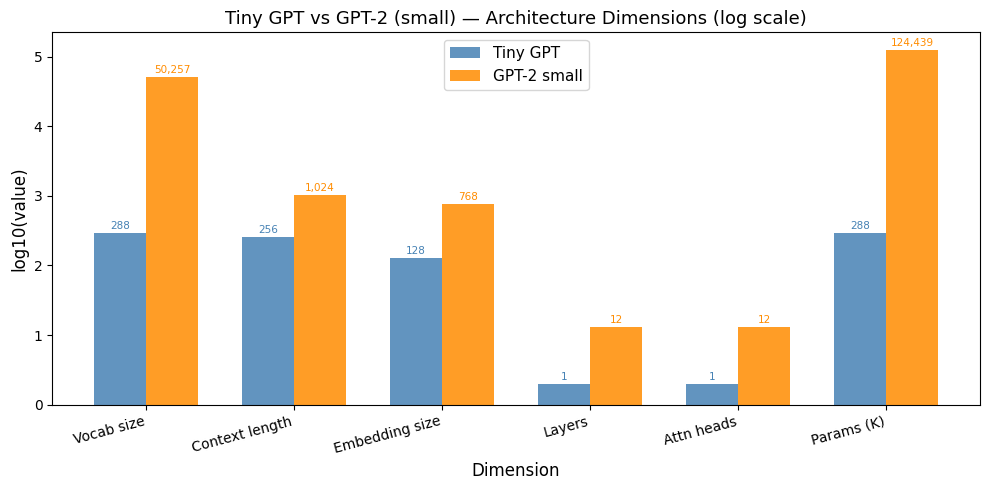

In [28]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    ("Vocab size",      tiny_vocab_size,     cfg.vocab_size),
    ("Context length",  tiny_context,        cfg.n_positions),
    ("Embedding size",  tiny_n_embd,         cfg.n_embd),
    ("Layers",          tiny_n_layers,       cfg.n_layer),
    ("Attn heads",      tiny_n_heads,        cfg.n_head),
    ("Params (K)",      tiny_params // 1000, gpt2_params // 1000),
]

labels    = [m[0] for m in metrics]
tiny_vals = np.array([m[1] for m in metrics], dtype=float)
gpt2_vals = np.array([m[2] for m in metrics], dtype=float)

tiny_log = np.log10(tiny_vals + 1)
gpt2_log = np.log10(gpt2_vals + 1)

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, tiny_log, w, label="Tiny GPT",    color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + w/2, gpt2_log, w, label="GPT-2 small", color="darkorange", alpha=0.85)

ax.set_xlabel("Dimension", fontsize=12)
ax.set_ylabel("log10(value)", fontsize=12)
ax.set_title("Tiny GPT vs GPT-2 (small) — Architecture Dimensions (log scale)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend(fontsize=11)

for bar, val in zip(bars1, tiny_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{int(val):,}", ha="center", va="bottom", fontsize=7.5, color="steelblue")
for bar, val in zip(bars2, gpt2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{int(val):,}", ha="center", va="bottom", fontsize=7.5, color="darkorange")

plt.tight_layout()
plt.show()

### Key differences summary

| Dimension | Tiny GPT | GPT-2 (small) | Scale factor |
|---|---|---|---|
| Vocabulary | 288 chars | 50,257 subwords | x175 |
| Context length | 256 tokens | 1,024 tokens | x4 |
| Embedding size | 128 | 768 | x6 |
| Transformer layers | 1 | 12 | x12 |
| Attention heads | 1 | 12 | x12 |
| Parameters | ~288 K | ~124 M | x431 |

- **Tokenization:** Tiny GPT works character by character (288 tokens).
  GPT-2 uses BPE subwords (50,257 tokens), capturing richer linguistic
  units and requiring fewer tokens per sentence.
- **Depth and width:** GPT-2 is 6x wider and 12x deeper, allowing it
  to capture higher-order relationships across layers.
- **Multi-head attention:** 12 heads let GPT-2 track syntax, coreference,
  and semantics simultaneously. Tiny GPT's single head handles only one
  relationship type at a time.
- **Scale:** GPT-2 has ~431x more parameters, trained on ~40 GB of web
  text vs. our small poetry corpus.

---
## Task 3 Recap

| Sub-task | What was done |
|---|---|
| **3.1** | Confirmed model loaded; printed full config |
| **3.2** | vocab=50,257 · context=1,024 · embd=768 · layers=12 · heads=12 |
| **3.3** | Explained wte + wpe; demonstrated addition giving (batch, T, 768) |
| **3.4** | ln_1 -> attn (masked) -> residual -> ln_2 -> mlp -> residual |
| **3.5** | FFN: Linear(768->3072) -> GELU -> Linear(3072->768) per token |
| **3.6** | ln_f -> lm_head (weight-tied to wte) -> softmax -> next-token probs |
| **3.7** | ~124 M params; most in the 12 transformer blocks |
| **3.8** | Comparison table + bar chart; GPT-2 is ~431x larger than Tiny GPT |

## Task 4: GPT-2 Attention Heads

Self-attention lets each token decide which earlier tokens matter. Each token
produces three vectors:
- Query (Q): what am I looking for?
- Key (K): what do I contain?
- Value (V): what information do I pass along?

Scores = Q·K (scaled), softmax turns them into weights that sum to 1, and the
weights mix the Value vectors:  Attention(Q,K,V) = softmax(QKᵀ/√d)·V

### 4.2 Causal masking
GPT-2 predicts the next token, so a token must not see future tokens.
Scores for future positions are set to -infinity before softmax, giving them weight 0.

In [29]:
import torch

seq_len = 5
scores = torch.randn(seq_len, seq_len)                 # fake attention scores
mask = torch.tril(torch.ones(seq_len, seq_len))        # 1 = allowed, 0 = future
masked = scores.masked_fill(mask == 0, float("-inf"))
weights = torch.softmax(masked, dim=-1)

print(mask)
print(weights.round(decimals=2))   # upper triangle is all 0, each row sums to 1

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6900, 0.3100, 0.0000, 0.0000, 0.0000],
        [0.4700, 0.3700, 0.1600, 0.0000, 0.0000],
        [0.3800, 0.1700, 0.1800, 0.2700, 0.0000],
        [0.2100, 0.1800, 0.3900, 0.0200, 0.1900]])


In [30]:
import torch

seq_len = 5
scores = torch.randn(seq_len, seq_len)                 # fake attention scores
mask = torch.tril(torch.ones(seq_len, seq_len))        # 1 = allowed, 0 = future
masked = scores.masked_fill(mask == 0, float("-inf"))
weights = torch.softmax(masked, dim=-1)

print(mask)
print(weights.round(decimals=2))   # upper triangle is all 0, each row sums to 1

tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5900, 0.4100, 0.0000, 0.0000, 0.0000],
        [0.0500, 0.6100, 0.3400, 0.0000, 0.0000],
        [0.1000, 0.0300, 0.0300, 0.8400, 0.0000],
        [0.4200, 0.0300, 0.2300, 0.2300, 0.1000]])


In [31]:
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

attn_model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    attn_implementation="eager",   # needed so attention weights are returned
    output_attentions=True,
).to(device).eval()

def get_attention(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = attn_model(**inputs)
    A = torch.stack(out.attentions).squeeze(1).cpu()
    toks = [t.replace("Ġ", "") for t in tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])]
    return A, toks

prompt = "The moon shines over the hills"
A, toks = get_attention(prompt)

print("Tokens:", toks)
print("Attention tensor (layers, heads, seq, seq):", A.shape)
print("Rows sum to 1?", torch.allclose(A.sum(-1), torch.ones_like(A.sum(-1)), atol=1e-4))
print("Weight on future tokens (should be 0):", torch.triu(A[0, 0], diagonal=1).sum().item())

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Tokens: ['The', 'moon', 'shines', 'over', 'the', 'hills']
Attention tensor (layers, heads, seq, seq): torch.Size([12, 12, 6, 6])
Rows sum to 1? True
Weight on future tokens (should be 0): 0.0


In [32]:
from transformers import GPT2LMHeadModel

attn_model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    attn_implementation="eager",   # needed so attention weights are returned
    output_attentions=True,
).to(device).eval()

def get_attention(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = attn_model(**inputs)
    # stack 12 layers -> (layers, heads, seq, seq)
    A = torch.stack(out.attentions).squeeze(1).cpu()
    toks = [t.replace("Ġ", "") for t in tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])]
    return A, toks

prompt = "The moon shines over the hills"
A, toks = get_attention(prompt)

print("Tokens:", toks)
print("Attention tensor (layers, heads, seq, seq):", A.shape)
print("Rows sum to 1?", torch.allclose(A.sum(-1), torch.ones_like(A.sum(-1)), atol=1e-4))
print("Weight on future tokens (should be 0):", torch.triu(A[0, 0], diagonal=1).sum().item())

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Tokens: ['The', 'moon', 'shines', 'over', 'the', 'hills']
Attention tensor (layers, heads, seq, seq): torch.Size([12, 12, 6, 6])
Rows sum to 1? True
Weight on future tokens (should be 0): 0.0


In [33]:
n_layers, n_heads = A.shape[0], A.shape[1]
print(f"Layers: {n_layers}, heads per layer: {n_heads}, total patterns: {n_layers * n_heads}")
print(f"Each head works on {attn_model.config.n_embd // n_heads} of the {attn_model.config.n_embd} embedding numbers")

Layers: 12, heads per layer: 12, total patterns: 144
Each head works on 64 of the 768 embedding numbers


GPT-2 small has 12 layers x 12 heads = 144 attention patterns. Each head has its own
Q, K, V weights, so each can learn a different relationship. The heads' outputs are
joined and mixed back together by c_proj.

In [34]:
prompts = [
    "The moon shines over the hills",
    "In the heart of Kigali",
    "The moon shines over the hills and the rain falls softly on the quiet village",
]

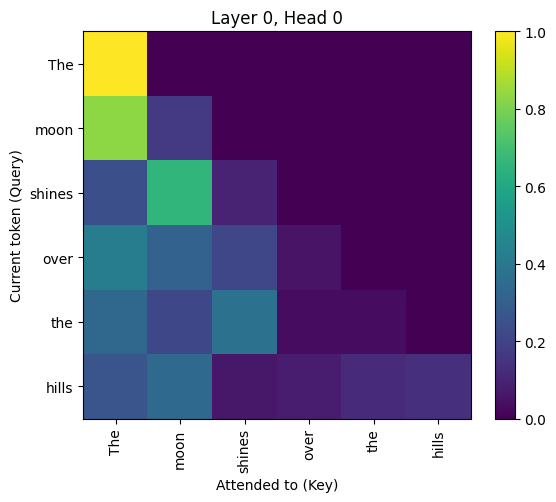

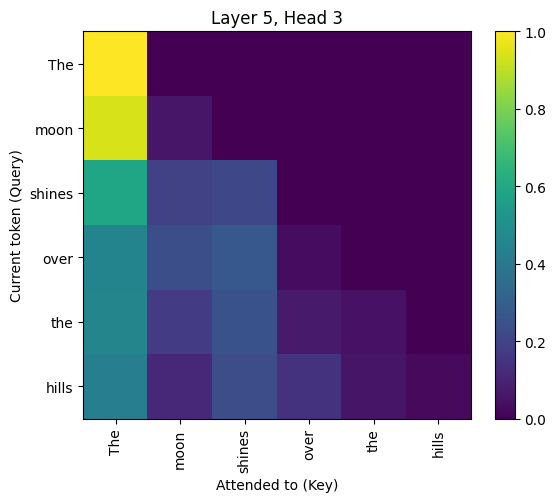

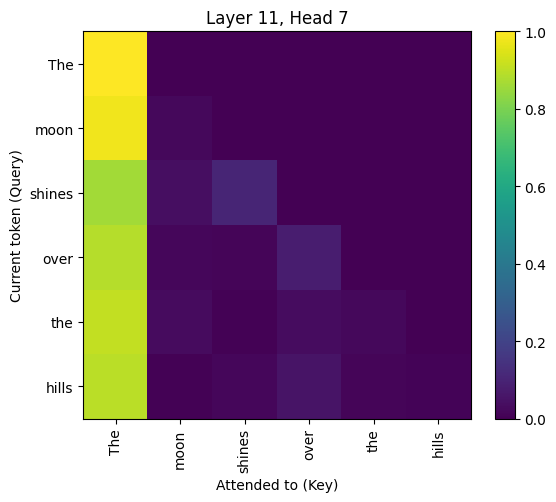

In [35]:
import matplotlib.pyplot as plt

def plot_head(A, toks, layer, head):
    plt.figure(figsize=(6, 5))
    plt.imshow(A[layer, head].numpy(), cmap="viridis")
    plt.xticks(range(len(toks)), toks, rotation=90)
    plt.yticks(range(len(toks)), toks)
    plt.xlabel("Attended to (Key)")
    plt.ylabel("Current token (Query)")
    plt.title(f"Layer {layer}, Head {head}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_head(A, toks, layer=0, head=0)
plot_head(A, toks, layer=5, head=3)
plot_head(A, toks, layer=11, head=7)

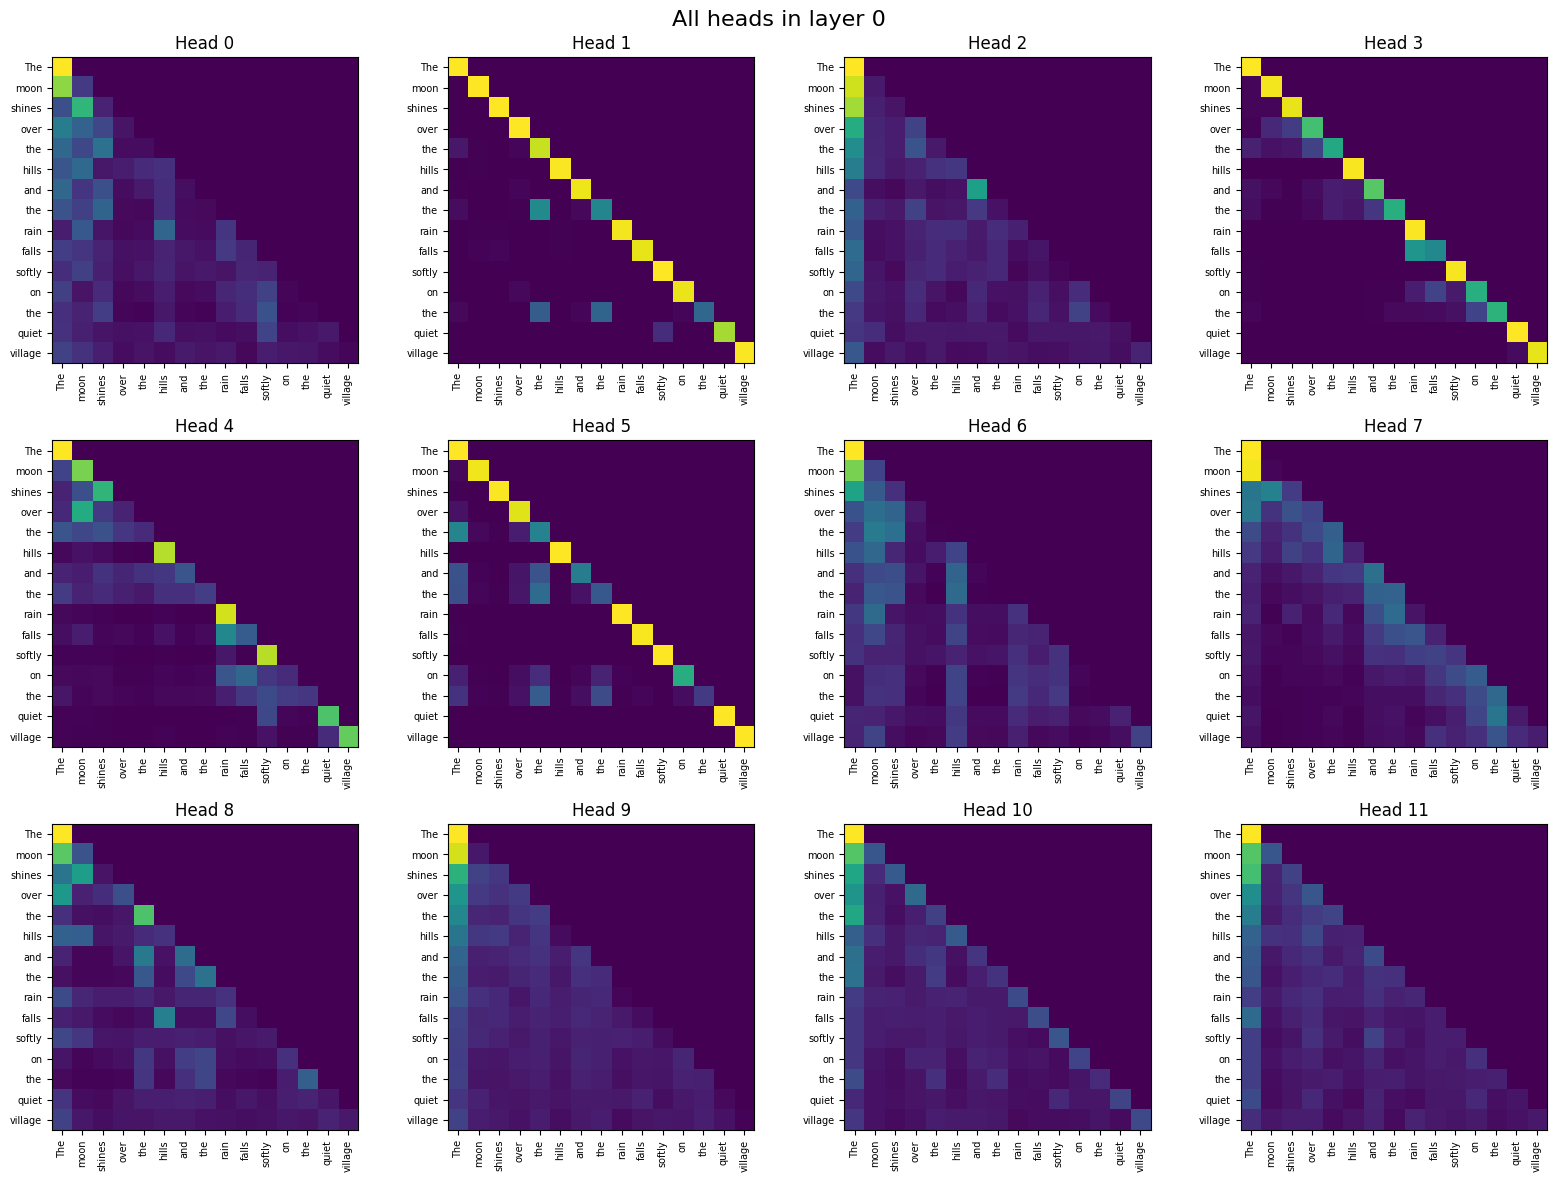

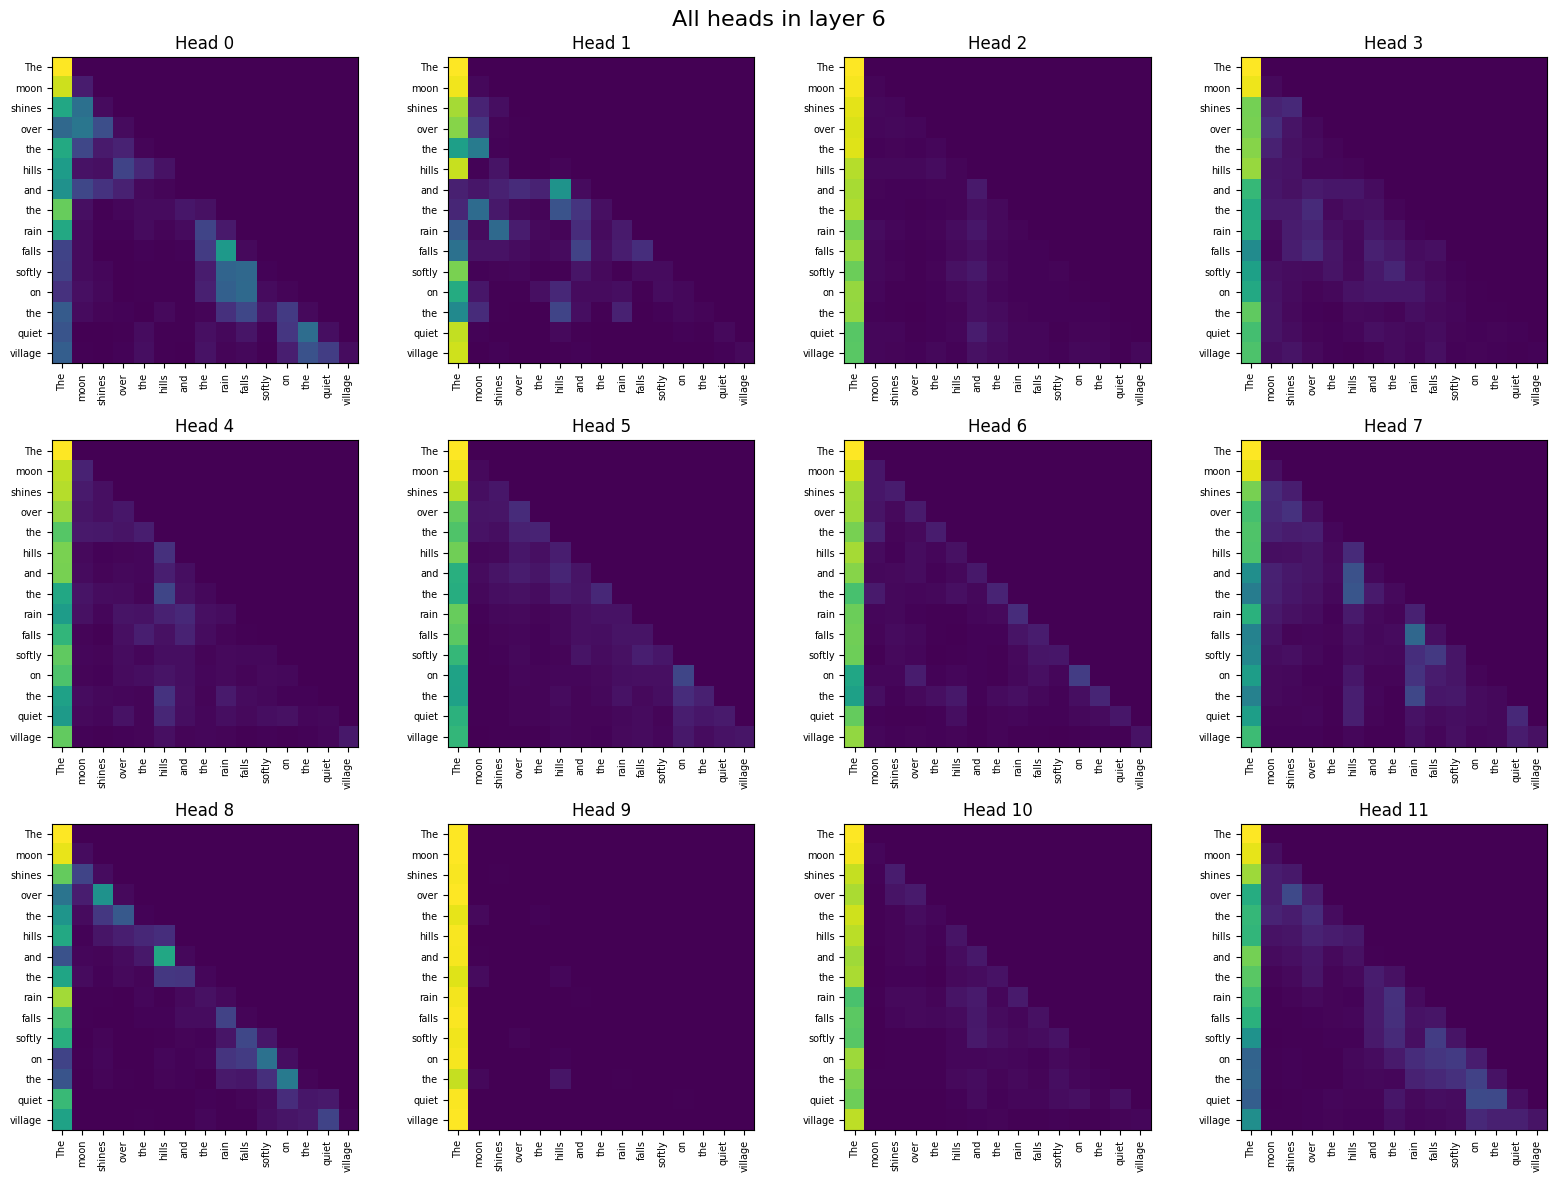

In [36]:
def plot_layer(A, toks, layer):
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    for h, ax in enumerate(axes.flat):
        ax.imshow(A[layer, h].numpy(), cmap="viridis")
        ax.set_title(f"Head {h}")
        ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=90, fontsize=7)
        ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks, fontsize=7)
    fig.suptitle(f"All heads in layer {layer}", fontsize=16)
    plt.tight_layout()
    plt.show()

A_long, toks_long = get_attention(prompts[2])
plot_layer(A_long, toks_long, layer=0)
plot_layer(A_long, toks_long, layer=6)

Strongest previous-token head: layer 4, head 11 (score 1.00)


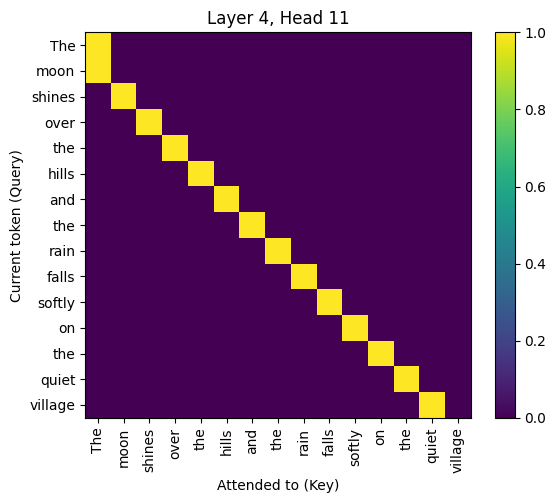

Strongest first-token head: layer 5, head 1 (score 0.99)


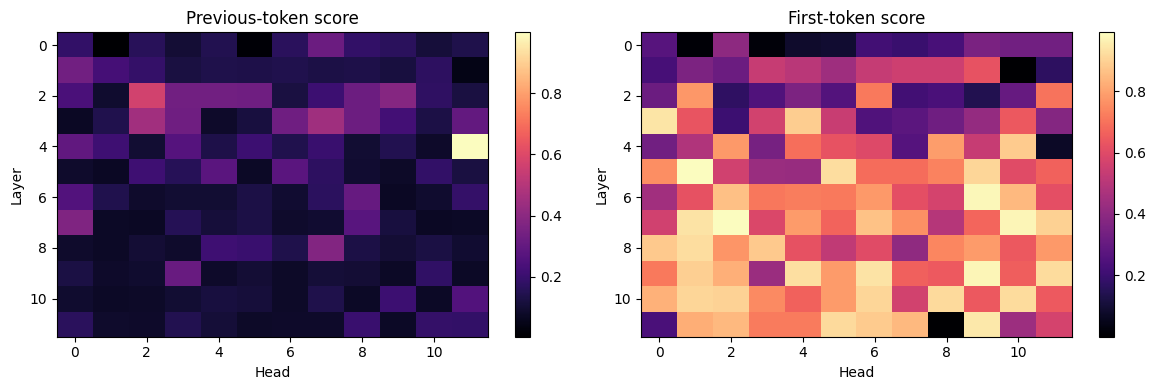

In [37]:
import matplotlib.pyplot as plt

n_layers, n_heads = A_long.shape[0], A_long.shape[1]
T = A_long.shape[-1]

# Previous-token score: how much each head attends to the word right before it
prev = torch.stack([A_long[:, :, i, i - 1] for i in range(1, T)]).mean(0)   # (layers, heads)

# First-token score: how much each head attends to the very first token
first = A_long[:, :, 1:, 0].mean(-1)                                         # (layers, heads)

l, h = divmod(prev.argmax().item(), n_heads)
print(f"Strongest previous-token head: layer {l}, head {h} (score {prev[l, h]:.2f})")
plot_head(A_long, toks_long, l, h)

l2, h2 = divmod(first.argmax().item(), n_heads)
print(f"Strongest first-token head: layer {l2}, head {h2} (score {first[l2, h2]:.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(axes, [prev, first], ["Previous-token score", "First-token score"]):
    im = ax.imshow(data.numpy(), cmap="magma", aspect="auto")
    ax.set_title(title); ax.set_xlabel("Head"); ax.set_ylabel("Layer")
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

### 4.7 Interpretation
- Some heads put most weight on the previous token (a bright line just below the diagonal).
- Many heads put a lot of weight on the first token, which seems to act as a default
  "resting place" when no other token is especially relevant.
- Other heads spread attention more broadly or show no clear pattern.

These are observations, not proof of what each head "means". Attention weights show
where information is read from, not a complete explanation of the model's behavior.

### 4.8 Tiny GPT link
Tiny GPT uses the same attention mechanism (Q/K/V, causal mask, softmax) but at a
smaller scale: fewer layers and heads and a smaller embedding size, trained on a small
poem dataset. Its attention was not extracted, so the comparison here is conceptual.